# Task 2: Structured Information Extraction with EBM-NLP

## Overview
This notebook addresses **Task 2: Structured Information Extraction** using the **EBM-NLP** dataset.

The coursework asks us to:
1. Explore whether natural clusters in the text correspond to schema fields.
2. Build and compare structured information extraction pipelines.
3. Evaluate quality using field-level metrics and coverage/precision trade-offs.
4. Discuss strengths, weaknesses, and practical usability.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path(r"/Users/priyanshugurjar/Downloads/AI AND TEXT/ebm_nlp_2_00")

if str(DATA_DIR) not in sys.path:
    sys.path.append(str(DATA_DIR))

from ebm_pio_experiments import (
    load_dataset,
    run_experiment,
)

print("Using dataset:", DATA_DIR)

Using dataset: /Users/priyanshugurjar/Downloads/AI AND TEXT/ebm_nlp_2_00


## Section 1: Understanding the Dataset Structure

In the next code cell we inspect the main dataset folders.

The important parts are:
- `documents/` for tokenized abstracts,
- `annotations/aggregated/hierarchical_labels/` for token-level labels.

In [2]:
documents_dir = DATA_DIR / "documents"
annotations_dir = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels"

print("Documents folder exists:", documents_dir.exists())
print("Annotations folder exists:", annotations_dir.exists())
print("Sample document files:")
print(sorted([p.name for p in documents_dir.glob("*.tokens")])[:5])

Documents folder exists: True
Annotations folder exists: True
Sample document files:
['10036953.tokens', '10037531.tokens', '10052279.tokens', '10070173.tokens', '10071998.tokens']


## Section 2: Loading the Three Schema Fields

We now load the three main schema fields from the EBM-NLP dataset:
- participants
- interventions
- outcomes

Each document is loaded as:
- `doc_id`
- `tokens`
- `BIO tags`

In [3]:
participants_train = load_dataset(DATA_DIR, "participants", "train")
participants_test = load_dataset(DATA_DIR, "participants", "test")

interventions_train = load_dataset(DATA_DIR, "interventions", "train")
interventions_test = load_dataset(DATA_DIR, "interventions", "test")

outcomes_train = load_dataset(DATA_DIR, "outcomes", "train")
outcomes_test = load_dataset(DATA_DIR, "outcomes", "test")

print("Participants:", len(participants_train), "train /", len(participants_test), "test")
print("Interventions:", len(interventions_train), "train /", len(interventions_test), "test")
print("Outcomes:", len(outcomes_train), "train /", len(outcomes_test), "test")

Participants: 4609 train / 189 test
Interventions: 4746 train / 187 test
Outcomes: 4681 train / 190 test


## Section 3: Inspecting One Example

The next cell shows one example document so that we can verify:
- the token sequence,
- and the matching BIO labels.

This is important because this is a **token-level extraction task**, not just a document classification task.

In [4]:
sample_doc = participants_train[0]
print("Document ID:", sample_doc.doc_id)
print("First 40 tokens:", sample_doc.tokens[:40])
print("First 40 BIO labels:", sample_doc.tags[:40])

Document ID: 10036953
First 40 tokens: ['[', 'Triple', 'therapy', 'regimens', 'involving', 'H2', 'blockaders', 'for', 'therapy', 'of', 'Helicobacter', 'pylori', 'infections', ']', '.', 'Comparison', 'of', 'ranitidine', 'and', 'lansoprazole', 'in', 'short-term', 'low-dose', 'triple', 'therapy', 'for', 'Helicobacter', 'pylori', 'infection', '.', 'To', 'evaluate', 'the', 'efficacy', 'and', 'safety', 'of', 'two', '1-week', 'low-dose']
First 40 BIO labels: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


## Section 4: Preliminary Clustering Analysis

This section answers the professor's first requirement.

We perform a preliminary clustering experiment to see whether the documents naturally group into the schema fields.

Important note:
- This is **exploratory analysis**.
- It is **not** the main extraction solution.
- The real task is still token/span extraction.

### Section 5: Building Document-Level Texts for Clustering

We convert each tokenized document into a single text string so that we can embed the whole abstract and cluster it.

In [6]:
cluster_rows = []

for doc in participants_train:
    cluster_rows.append({"doc_id": doc.doc_id, "text": " ".join(doc.tokens), "true_label": "P"})
for doc in interventions_train:
    cluster_rows.append({"doc_id": doc.doc_id, "text": " ".join(doc.tokens), "true_label": "I"})
for doc in outcomes_train:
    cluster_rows.append({"doc_id": doc.doc_id, "text": " ".join(doc.tokens), "true_label": "O"})

cluster_df = pd.DataFrame(cluster_rows)
print(cluster_df.shape)
cluster_df.head()

(14036, 3)


,doc_id,text,true_label
0,10036953,[ Triple therapy regimens involving H2 blockad...,P
1,10037531,Xylitol for prevention of acute otitis media .,P
2,10052279,Pre-operative short-term pulmonary rehabilitat...,P
3,10071998,Anesthesia for in vitro fertilization : the ad...,P
4,10073522,Fertility outcome after systemic methotrexate ...,P


### Section 6: Generating Sentence Embeddings and Running K-Means / HAC

We use a compact sentence embedding model and compare:
- K-Means clustering
- Hierarchical Agglomerative Clustering (HAC)

We evaluate clustering quality with:
- ARI
- NMI

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

model_name = "huawei-noah/TinyBERT_General_4L_312D"
embedder = SentenceTransformer(model_name)

sample_cluster_df = cluster_df.sample(n=min(1500, len(cluster_df)), random_state=13).reset_index(drop=True)
embeddings = embedder.encode(
    sample_cluster_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sample_cluster_df["kmeans_cluster"] = kmeans.fit_predict(embeddings)

hac = AgglomerativeClustering(n_clusters=3, linkage="ward")
sample_cluster_df["hac_cluster"] = hac.fit_predict(embeddings)

def clustering_scores(true_labels, pred_labels):
    return {
        "ARI": adjusted_rand_score(true_labels, pred_labels),
        "NMI": normalized_mutual_info_score(true_labels, pred_labels),
    }

kmeans_scores = clustering_scores(sample_cluster_df["true_label"], sample_cluster_df["kmeans_cluster"])
hac_scores = clustering_scores(sample_cluster_df["true_label"], sample_cluster_df["hac_cluster"])

pd.DataFrame([
    {"method": "K-Means", **kmeans_scores},
    {"method": "HAC", **hac_scores},
])

No sentence-transformers model found with name huawei-noah/TinyBERT_General_4L_312D. Creating a new one with mean pooling.


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

,method,ARI,NMI
0,K-Means,-0.000596,0.000352
1,HAC,0.000273,0.001201


### Section 6: Interpretation of the Clustering Stage

This clustering stage is useful for answering the coursework requirement, but it should be interpreted carefully.

If clusters align poorly with true schema labels, that does **not** mean extraction is impossible.
It only means that the whole abstracts do not naturally separate cleanly at document level.

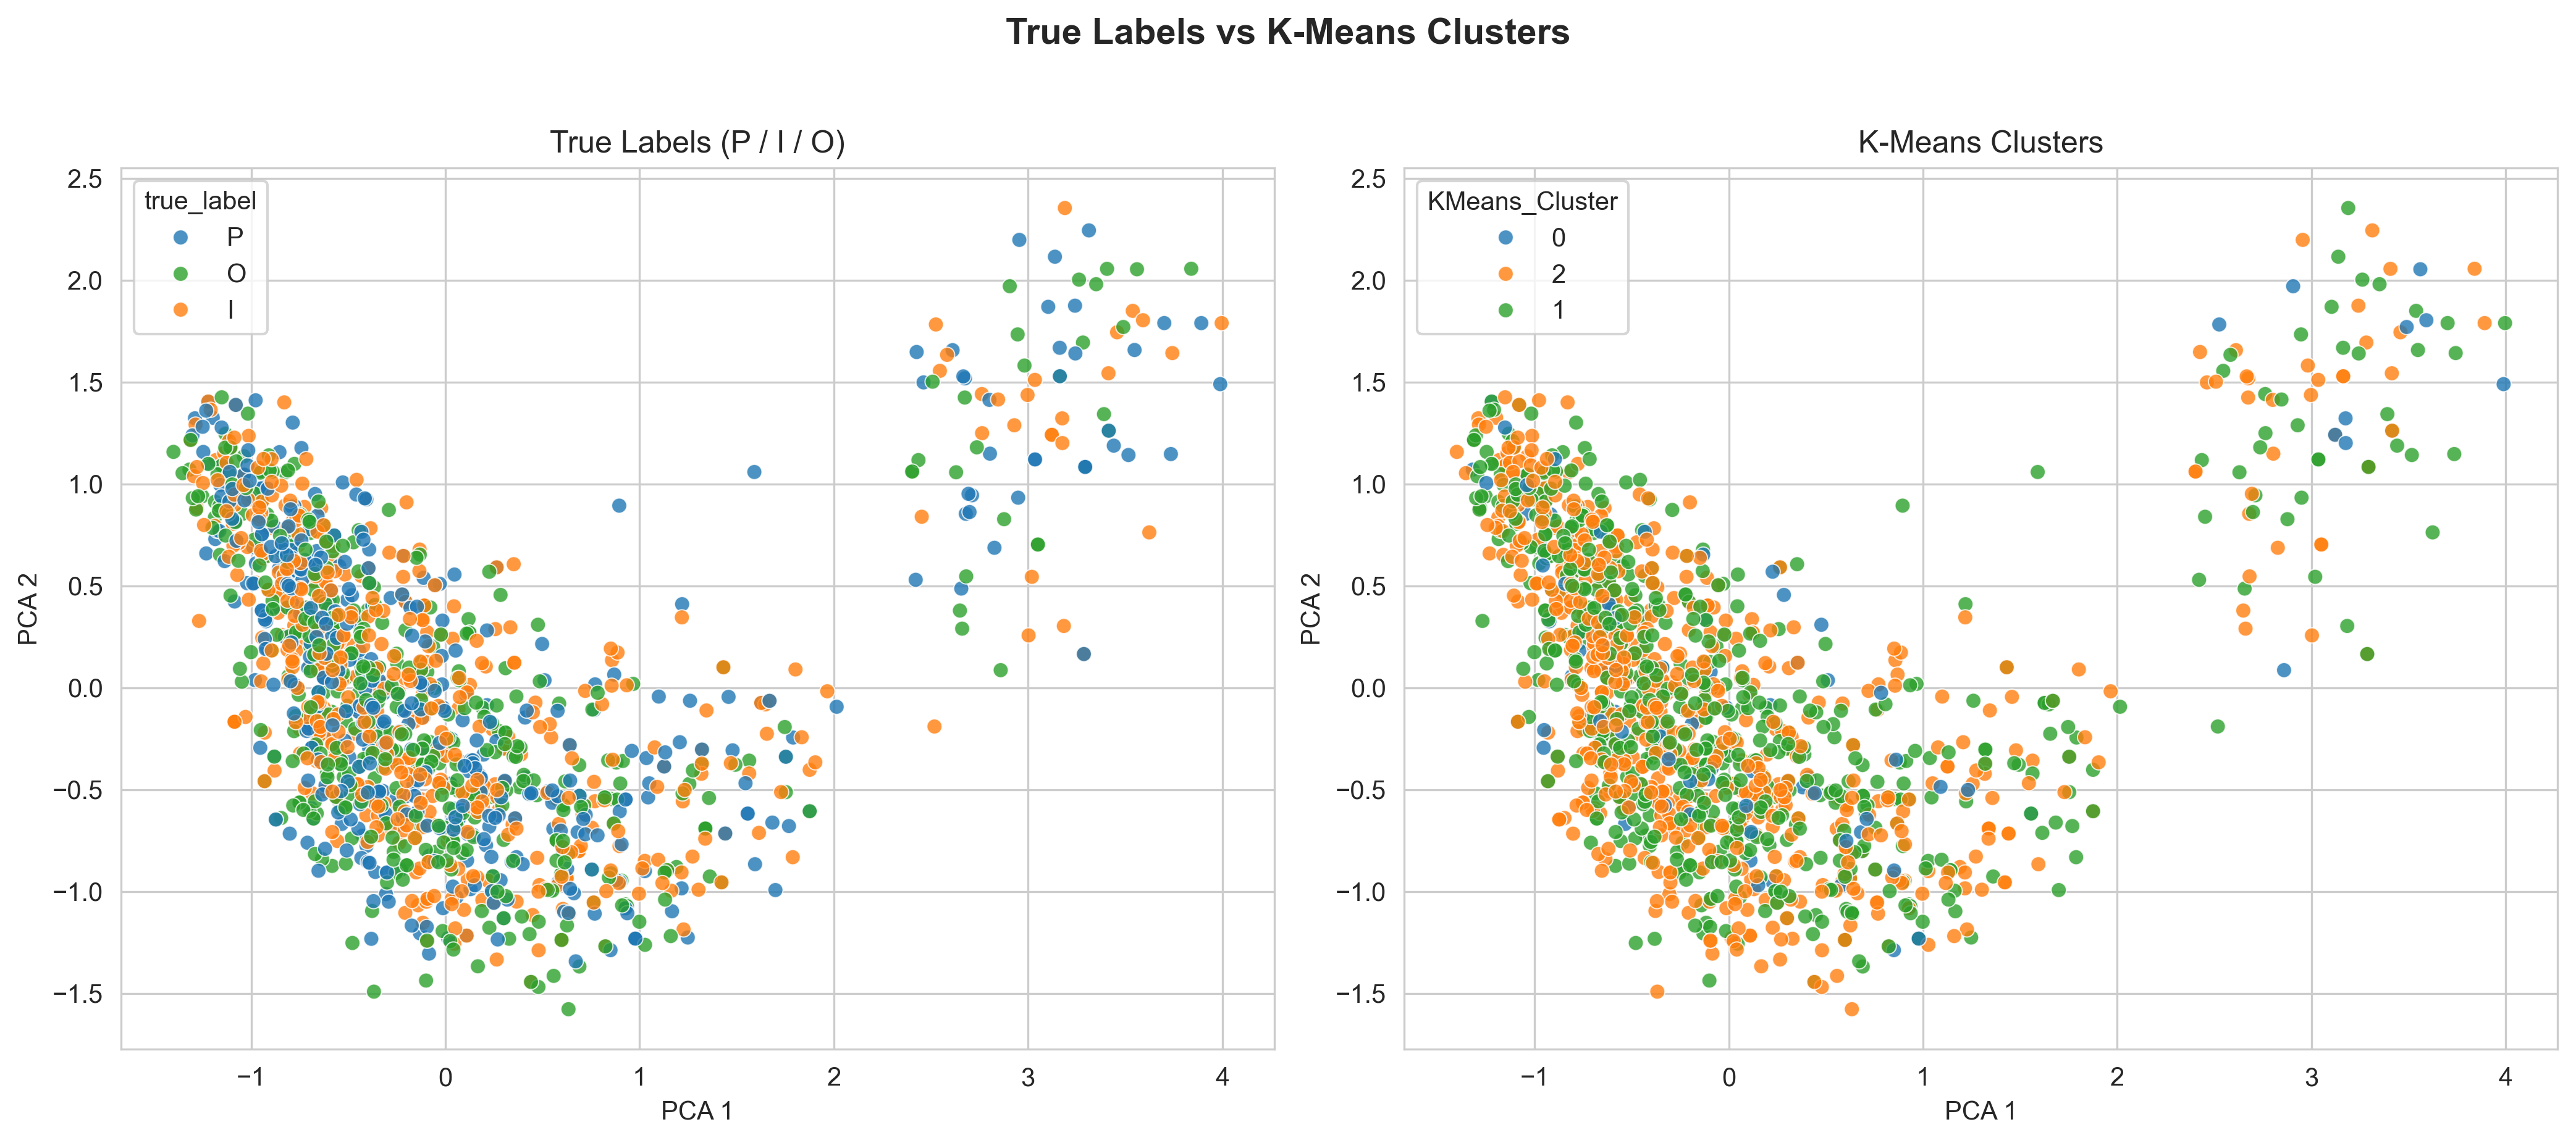

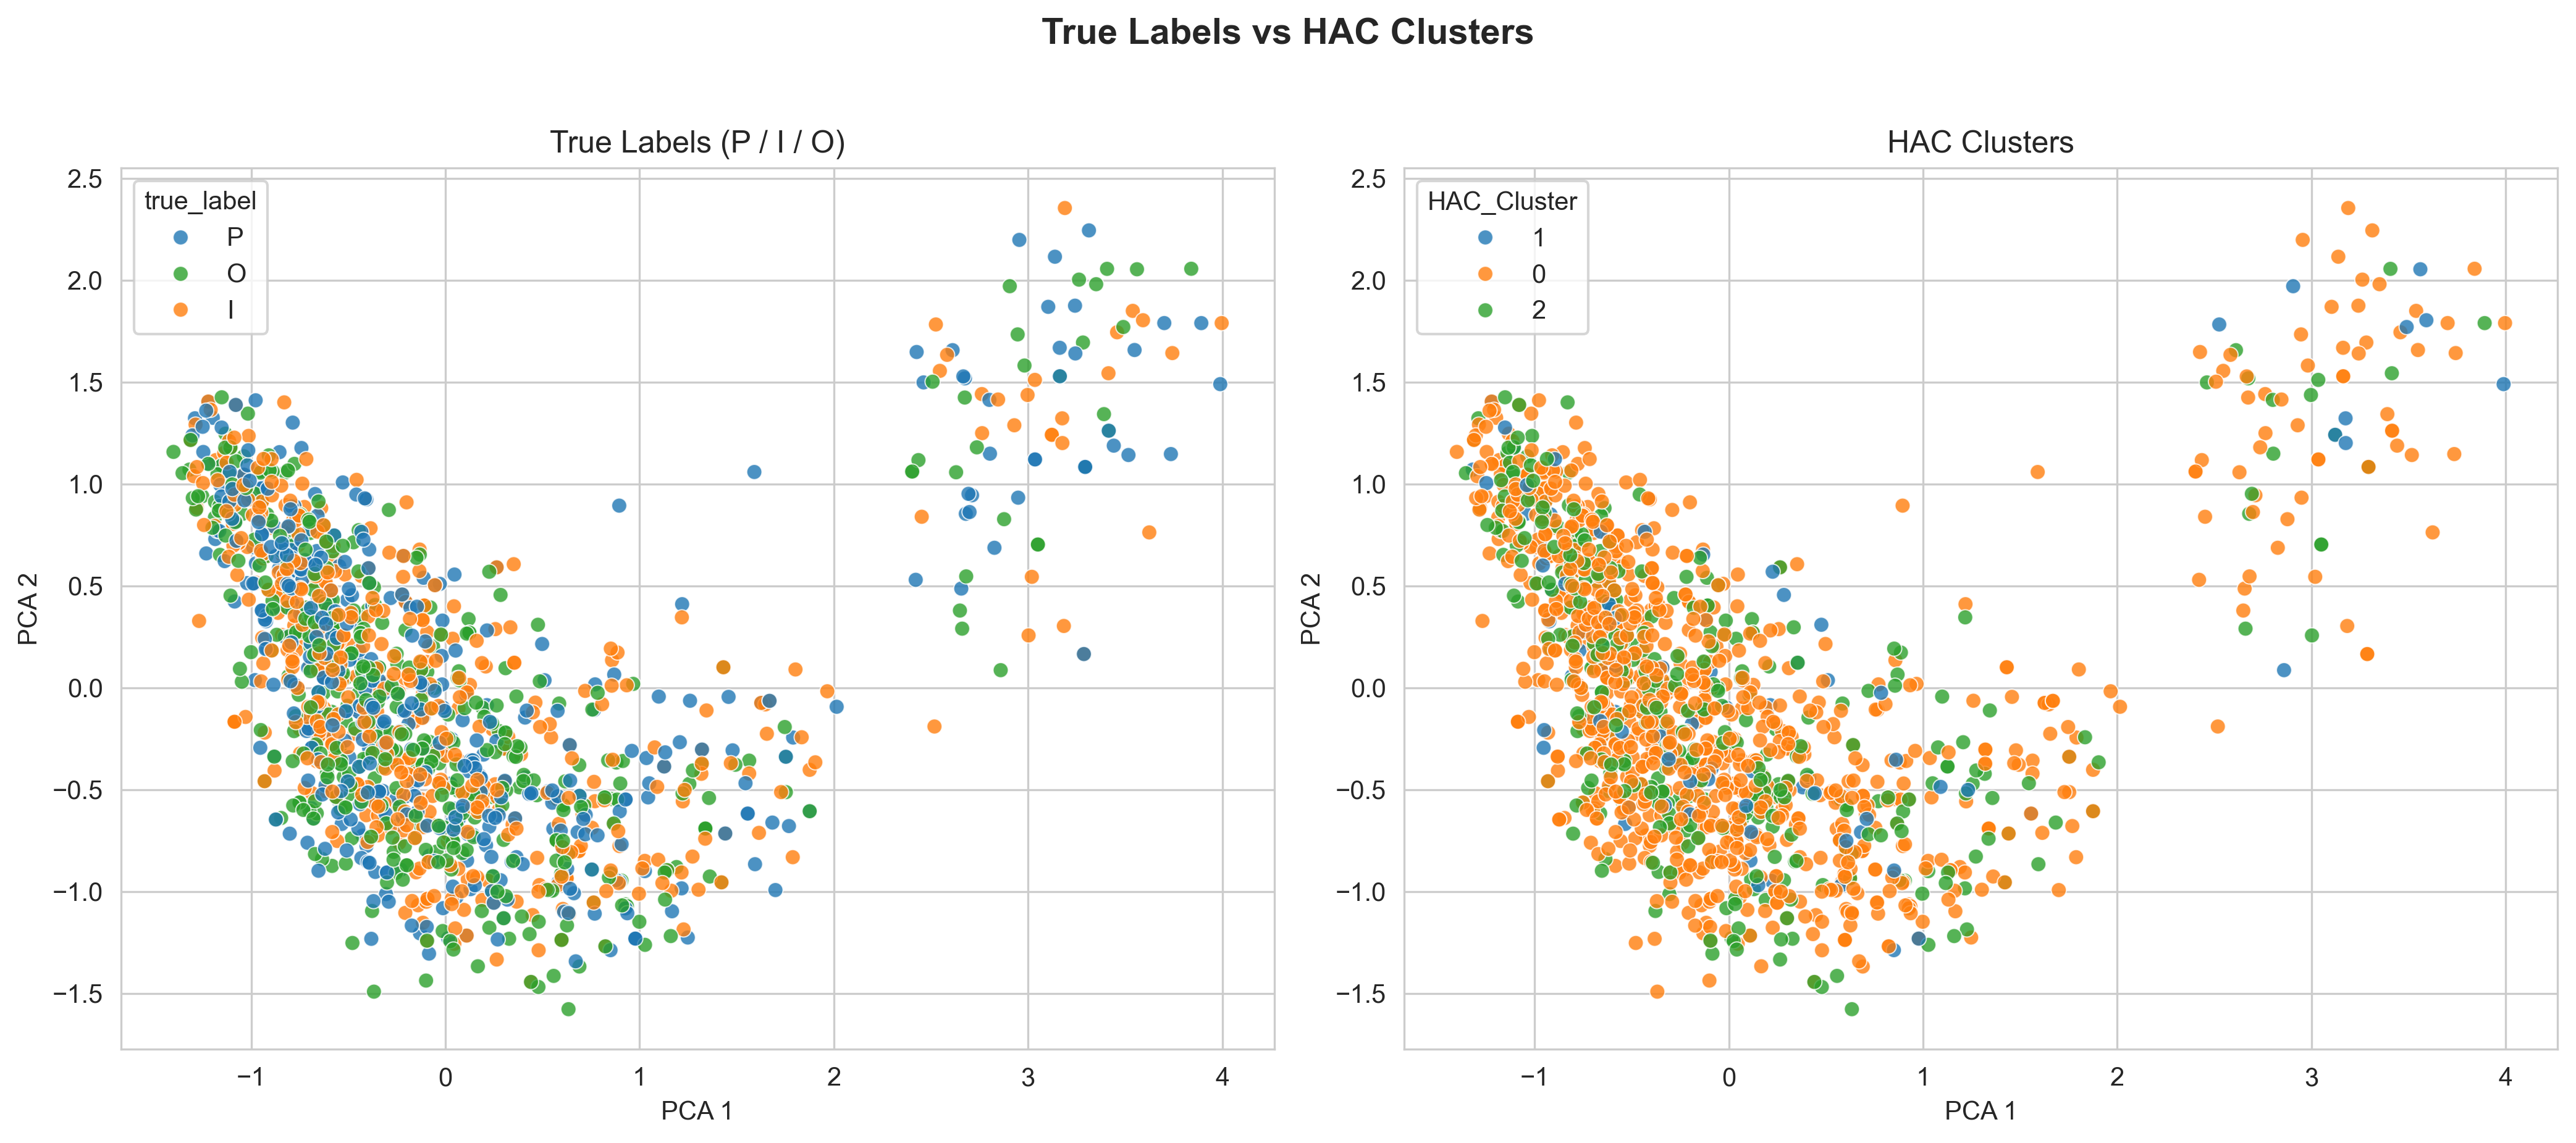

In [13]:
# Section 6.4: Visualising Why Clustering Is Not Helpful

from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 300

# Reduce embeddings to 2D for plotting
pca = PCA(n_components=2, random_state=42)
embedding_2d = pca.fit_transform(embeddings)

plot_df = sample_cluster_df.copy()
plot_df["PC1"] = embedding_2d[:, 0]
plot_df["PC2"] = embedding_2d[:, 1]
plot_df["KMeans_Cluster"] = plot_df["kmeans_cluster"].astype(str)
plot_df["HAC_Cluster"] = plot_df["hac_cluster"].astype(str)

# Figure 1: True labels vs K-Means
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="true_label",
    palette={"P": "#1f77b4", "I": "#ff7f0e", "O": "#2ca02c"},
    s=35, alpha=0.8, ax=axes[0]
)
axes[0].set_title("True Labels (P / I / O)")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="KMeans_Cluster",
    palette="tab10",
    s=35, alpha=0.8, ax=axes[1]
)
axes[1].set_title("K-Means Clusters")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

plt.suptitle("True Labels vs K-Means Clusters", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Figure 2: True labels vs HAC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="true_label",
    palette={"P": "#1f77b4", "I": "#ff7f0e", "O": "#2ca02c"},
    s=35, alpha=0.8, ax=axes[0]
)
axes[0].set_title("True Labels (P / I / O)")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="HAC_Cluster",
    palette="tab10",
    s=35, alpha=0.8, ax=axes[1]
)
axes[1].set_title("HAC Clusters")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

plt.suptitle("True Labels vs HAC Clusters", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



The true labels do not form clearly separated regions, and the K-Means/HAC cluster colours
do not align with the real P/I/O labels. This visually confirms the ARI and NMI scores near zero.
Therefore, document-level clustering is not useful as a final solution for this task.
The real task requires token-level extraction rather than document-level grouping.

## Section 7: Main Extraction Experiment

This is the core of the notebook.

We compare two model designs:
- **End-to-end**: directly predict BIO tags.
- **Decomposed**: first detect entity vs non-entity, then convert into BIO spans.

We also compare three learning strategies:
- **Zero-shot**
- **Few-shot**
- **Full-train**

### Section 7.1: Running All Extraction Experiments

The next code cell runs all combinations across:
- participants
- interventions
- outcomes

In [14]:
def run_all_experiments(entity_types=("participants", "interventions", "outcomes"),
                        few_shot_docs=40,
                        epochs=2,
                        seed=13):
    results = []
    for entity_type in entity_types:
        train_docs = load_dataset(DATA_DIR, entity_type, "train")
        test_docs = load_dataset(DATA_DIR, entity_type, "test")
        print(f"[{entity_type}] train_docs={len(train_docs)} test_docs={len(test_docs)}")

        for formulation in ("end-to-end", "decomposed"):
            for strategy in ("zero-shot", "few-shot", "full-train"):
                print(f"  running {formulation:11} + {strategy:9} ...")
                results.append(
                    run_experiment(
                        entity_type=entity_type,
                        train_docs=train_docs,
                        test_docs=test_docs,
                        formulation=formulation,
                        strategy=strategy,
                        few_shot_docs=few_shot_docs,
                        seed=seed,
                        epochs=epochs,
                    )
                )
    return pd.DataFrame(results)

### Section 7.2: Executing the Experiment Grid

This cell produces the main result table.

In [15]:
results_df = run_all_experiments(few_shot_docs=40, epochs=2, seed=13)
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
results_df

[participants] train_docs=4609 test_docs=189
  running end-to-end  + zero-shot ...
  running end-to-end  + few-shot  ...
  running end-to-end  + full-train ...
  running decomposed  + zero-shot ...
  running decomposed  + few-shot  ...
  running decomposed  + full-train ...
[interventions] train_docs=4746 test_docs=187
  running end-to-end  + zero-shot ...
  running end-to-end  + few-shot  ...
  running end-to-end  + full-train ...
  running decomposed  + zero-shot ...
  running decomposed  + few-shot  ...
  running decomposed  + full-train ...
[outcomes] train_docs=4681 test_docs=190
  running end-to-end  + zero-shot ...
  running end-to-end  + few-shot  ...
  running end-to-end  + full-train ...
  running decomposed  + zero-shot ...
  running decomposed  + few-shot  ...
  running decomposed  + full-train ...


,entity_type,formulation,strategy,train_docs_used,precision,recall,f1,token_accuracy,coverage,usable_doc_rate,exact_doc_match_rate,gold_docs_with_entity,pred_docs_with_entity,tp,fp,fn
0,interventions,end-to-end,full-train,4746,0.611244,0.339535,0.436566,0.954620,0.759358,0.577540,0.042781,185.0,142.0,511.0,325.0,994.0
1,interventions,decomposed,full-train,4746,0.561975,0.355482,0.435490,0.953422,0.791444,0.582888,0.037433,185.0,148.0,535.0,417.0,970.0
2,outcomes,decomposed,full-train,4681,0.224490,0.167270,0.191701,0.919325,0.900000,0.478947,0.015789,186.0,171.0,231.0,798.0,1150.0
3,outcomes,end-to-end,full-train,4681,0.228774,0.140478,0.174069,0.922155,0.889474,0.452632,0.010526,186.0,169.0,194.0,654.0,1187.0
4,interventions,decomposed,few-shot,40,0.507194,0.093688,0.158160,0.945139,0.475936,0.299465,0.016043,185.0,89.0,141.0,137.0,1364.0
5,participants,decomposed,full-train,4609,0.165591,0.112738,0.134146,0.938422,0.804233,0.291005,0.005291,188.0,152.0,77.0,388.0,606.0
6,interventions,end-to-end,few-shot,40,0.488889,0.073090,0.127168,0.944707,0.417112,0.262032,0.010695,185.0,78.0,110.0,115.0,1395.0
7,participants,end-to-end,full-train,4609,0.160671,0.098097,0.121818,0.939047,0.793651,0.248677,0.010582,188.0,150.0,67.0,350.0,616.0
8,participants,decomposed,few-shot,40,0.233871,0.042460,0.071871,0.933637,0.343915,0.116402,0.010582,188.0,65.0,29.0,95.0,654.0
9,participants,end-to-end,zero-shot,0,0.055860,0.074671,0.063910,0.903678,0.936508,0.211640,0.021164,188.0,177.0,51.0,862.0,632.0


## Section 8: Evaluating Field-Level Performance

We now inspect the main extraction metrics:
- precision
- recall
- F1
- token accuracy

This is the most important quantitative evaluation section.

In [17]:
results_df[[
    "entity_type", "formulation", "strategy", "train_docs_used",
    "precision", "recall", "f1", "token_accuracy"
]].sort_values("f1", ascending=False)

,entity_type,formulation,strategy,train_docs_used,precision,recall,f1,token_accuracy
0,interventions,end-to-end,full-train,4746,0.611244,0.339535,0.436566,0.954620
1,interventions,decomposed,full-train,4746,0.561975,0.355482,0.435490,0.953422
2,outcomes,decomposed,full-train,4681,0.224490,0.167270,0.191701,0.919325
3,outcomes,end-to-end,full-train,4681,0.228774,0.140478,0.174069,0.922155
4,interventions,decomposed,few-shot,40,0.507194,0.093688,0.158160,0.945139
5,participants,decomposed,full-train,4609,0.165591,0.112738,0.134146,0.938422
6,interventions,end-to-end,few-shot,40,0.488889,0.073090,0.127168,0.944707
7,participants,end-to-end,full-train,4609,0.160671,0.098097,0.121818,0.939047
8,participants,decomposed,few-shot,40,0.233871,0.042460,0.071871,0.933637
10,participants,decomposed,zero-shot,0,0.055860,0.074671,0.063910,0.903678


## Section 9: Coverage vs Precision Trade-Off

The coursework also asks us to study **coverage vs precision**.

Here:
- `coverage` tells us how often the model extracts at least something from a document,
- `precision` tells us how often those extracted spans are correct,
- `usable_doc_rate` gives a rough practical measure of whether at least one correct span is recovered in a document.

In [18]:
results_df[[
    "entity_type", "formulation", "strategy",
    "precision", "recall", "f1", "coverage", "usable_doc_rate"
]].sort_values(["entity_type", "f1"], ascending=[True, False])

,entity_type,formulation,strategy,precision,recall,f1,coverage,usable_doc_rate
0,interventions,end-to-end,full-train,0.611244,0.339535,0.436566,0.759358,0.577540
1,interventions,decomposed,full-train,0.561975,0.355482,0.435490,0.791444,0.582888
4,interventions,decomposed,few-shot,0.507194,0.093688,0.158160,0.475936,0.299465
6,interventions,end-to-end,few-shot,0.488889,0.073090,0.127168,0.417112,0.262032
16,interventions,end-to-end,zero-shot,0.035366,0.019269,0.024946,0.828877,0.128342
17,interventions,decomposed,zero-shot,0.035366,0.019269,0.024946,0.828877,0.128342
2,outcomes,decomposed,full-train,0.224490,0.167270,0.191701,0.900000,0.478947
3,outcomes,end-to-end,full-train,0.228774,0.140478,0.174069,0.889474,0.452632
11,outcomes,end-to-end,few-shot,0.250000,0.027516,0.049576,0.436842,0.147368
12,outcomes,end-to-end,zero-shot,0.066580,0.036930,0.047508,0.905263,0.200000


## Section 10: Best Configuration Per Entity Type

This cell identifies the strongest pipeline for each schema field.

In [19]:
best_per_entity = results_df.groupby("entity_type", as_index=False).first()
best_per_entity[[
    "entity_type", "formulation", "strategy", "precision", "recall", "f1", "coverage", "usable_doc_rate"
]]

,entity_type,formulation,strategy,precision,recall,f1,coverage,usable_doc_rate
0,interventions,end-to-end,full-train,0.611244,0.339535,0.436566,0.759358,0.577540
1,outcomes,decomposed,full-train,0.224490,0.167270,0.191701,0.900000,0.478947
2,participants,decomposed,full-train,0.165591,0.112738,0.134146,0.804233,0.291005


## Section 11: Average Performance Across Entity Types

To compare end-to-end and decomposed pipelines more fairly, we average F1 across the three entity types.

This helps answer the question:
**Which design is stronger overall, not just on one field?**

In [20]:
avg_results = (
    results_df.groupby(["formulation", "strategy"], as_index=False)["f1"]
    .mean()
    .rename(columns={"f1": "avg_f1"})
    .sort_values("avg_f1", ascending=False)
)
avg_results

,formulation,strategy,avg_f1
1,decomposed,full-train,0.253779
4,end-to-end,full-train,0.244151
0,decomposed,few-shot,0.092118
3,end-to-end,few-shot,0.067745
2,decomposed,zero-shot,0.045455
5,end-to-end,zero-shot,0.045455


## Section 12: Visualization of Extraction Performance

We create a bar chart so that differences between model designs are easier to see.

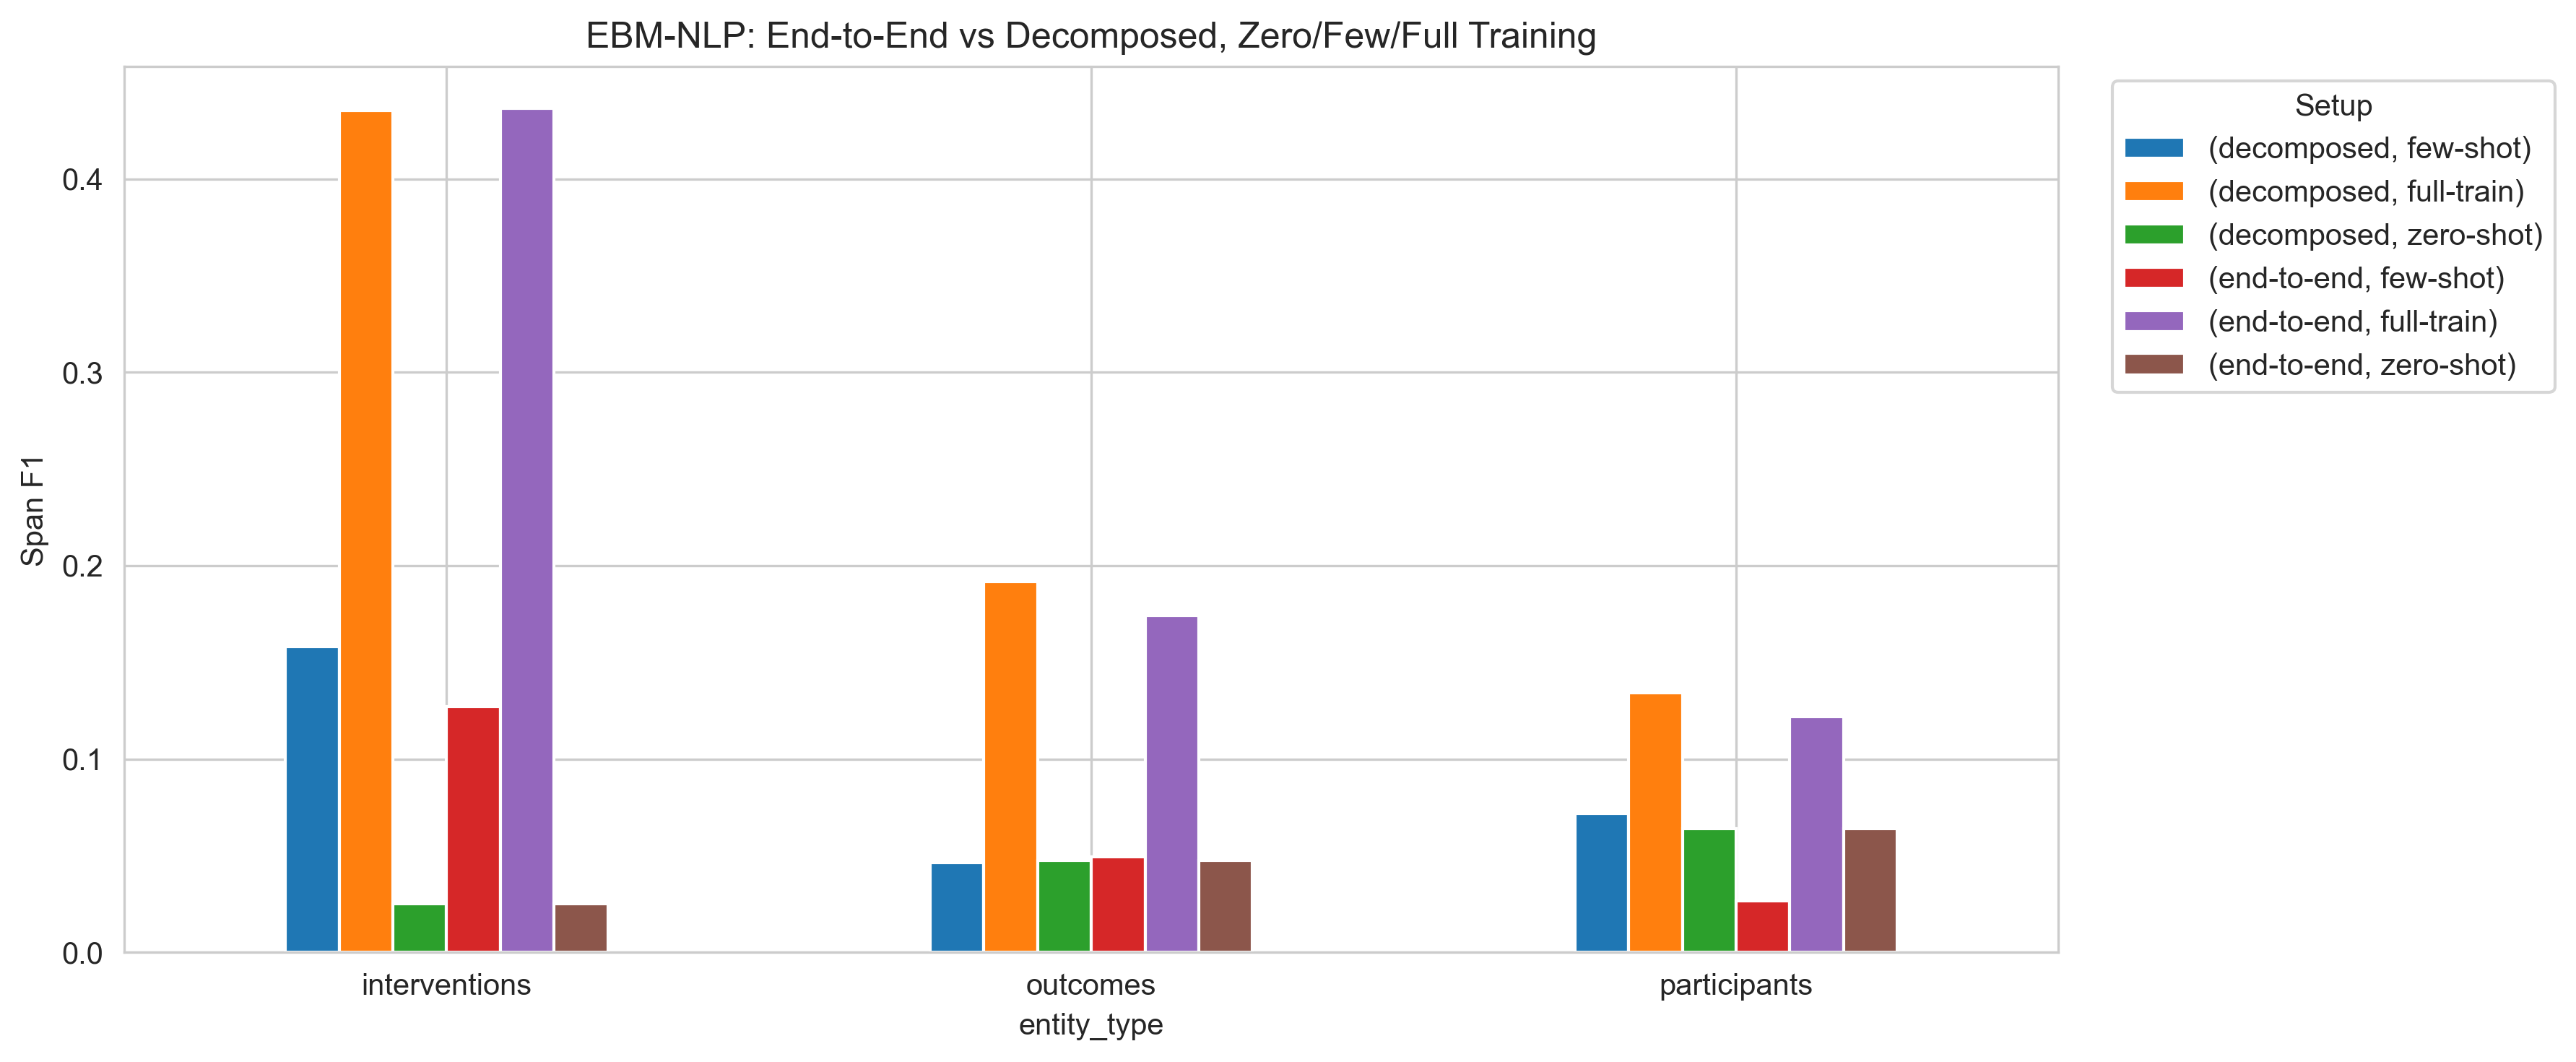

In [21]:
pivot_df = results_df.pivot_table(
    index="entity_type",
    columns=["formulation", "strategy"],
    values="f1"
)

pivot_df.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Span F1")
plt.title("EBM-NLP: End-to-End vs Decomposed, Zero/Few/Full Training")
plt.xticks(rotation=0)
plt.legend(title="Setup", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Figure X shows span-level F1 for end-to-end and decomposed extraction pipelines under zero-shot, few-shot, and full-training settings. Full training clearly outperforms the weaker supervision settings across all entity types. Interventions are the easiest field to extract, while participants and outcomes remain more difficult. Decomposed extraction performs slightly better overall, although end-to-end full training achieves the best single result for interventions.